# Data Science Fundamentals Project  
**Group: H**  
**Domain**: Economics (TT5L)  
**Dataset**: African Crises Dataset  

This notebook investigates the early indicators and comparative patterns of financial crises in African countries using data analysis and machine learning models.


Import libraries: 

In [19]:
import pandas as pd      #read CSV file
import matplotlib.pyplot as plt    #barchart
import seaborn as sns   #for boxplot

## Research Question 1
**Does high inflation increase the chance of a systemic crisis in African countries?**

1. Load dataset


In [23]:
#load data
df = pd.read_csv("african_crises.csv")
df

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1054,70,ZWE,Zimbabwe,2009,1,354.800000,1,1,0.0,-7.670000,1,1,0,crisis
1055,70,ZWE,Zimbabwe,2010,0,378.200000,1,1,0.0,3.217000,1,0,0,no_crisis
1056,70,ZWE,Zimbabwe,2011,0,361.900000,1,1,0.0,4.920000,1,0,0,no_crisis
1057,70,ZWE,Zimbabwe,2012,0,361.900000,1,1,0.0,3.720000,1,0,0,no_crisis


2. Data cleanning and checking:

In [26]:
#check for data type
df_datatype=df.info()
#check for missing values
missing_value= df.isnull().sum()
#display
df_datatype, missing_value

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

(None,
 case                               0
 cc3                                0
 country                            0
 year                               0
 systemic_crisis                    0
 exch_usd                           0
 domestic_debt_in_default           0
 sovereign_external_debt_default    0
 gdp_weighted_default               0
 inflation_annual_cpi               0
 independence                       0
 currency_crises                    0
 inflation_crises                   0
 banking_crisis                     0
 dtype: int64)

As for research question 1 , we only focus on the systemic_crisis and inflation_annual_cpi columns, and from the above result, these 2 columns have the correct data type. Besides that, the dataset is also clean in terms of missing values, so we can proceed to the next step.

3. Initial Boxplot of Inflation vs Systemic Crisis

We first illustrate the distribution of annual inflation rates for both crisis years and non-crisis years with a boxplot.  This allows us to see any differences or outliers in the data

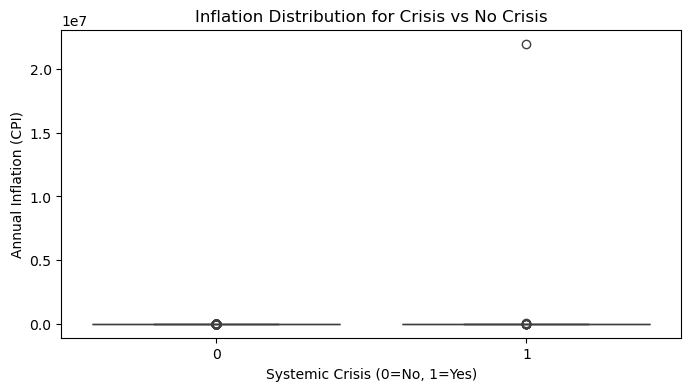

In [31]:
#create a figure with size and resolution
fig = plt.figure(figsize=(8,4), dpi=100)  
#boxplot
sns.boxplot(x='systemic_crisis', y='inflation_annual_cpi', data=df)
plt.title('Inflation Distribution for Crisis vs No Crisis')
plt.xlabel('Systemic Crisis (0=No, 1=Yes)')
plt.ylabel('Annual Inflation (CPI)')
#display boxplot
plt.show()
#save the plot as png image in working dir
fig.savefig("boxplot.png")  

As we can observed, the plot looked distorted and empty because of extreme inflation values (reaching up to millions), likely due to hyperinflation (rapid increase in prices). These  values are so high that the distribution seems compressed and shows little variation. To solve this, a cap was applied to limit inflation values to a maximum threshold of 1000%. This method prevent outliers from disorting the plot, enabling a clearer comparison between crisis and non-crisis periods.



Before capping the inflation values, we examined the dataset to identify extreme inflation cases that could distort our analysis. Using the filter below, we print rows where the annual inflation rate exceeded 1000%:

In [35]:
# Filter rows where inflation is higher than 1000%
high_inflation = df[df['inflation_annual_cpi'] > 1000]

# Display the rows with high inflation
print(high_inflation)

      case  cc3   country  year  systemic_crisis      exch_usd  \
140      2  AGO    Angola  1993                0  6.500000e-06   
142      2  AGO    Angola  1995                0  5.692000e-03   
143      2  AGO    Angola  1996                0  2.019940e-01   
1051    70  ZWE  Zimbabwe  2006                1  3.000000e-19   
1052    70  ZWE  Zimbabwe  2007                1  1.900000e-16   
1053    70  ZWE  Zimbabwe  2008                1  2.000000e-03   

      domestic_debt_in_default  sovereign_external_debt_default  \
140                          1                                1   
142                          1                                1   
143                          1                                1   
1051                         1                                1   
1052                         1                                1   
1053                         1                                1   

      gdp_weighted_default  inflation_annual_cpi  independence  \
1

4. Boxplot with capped inflation

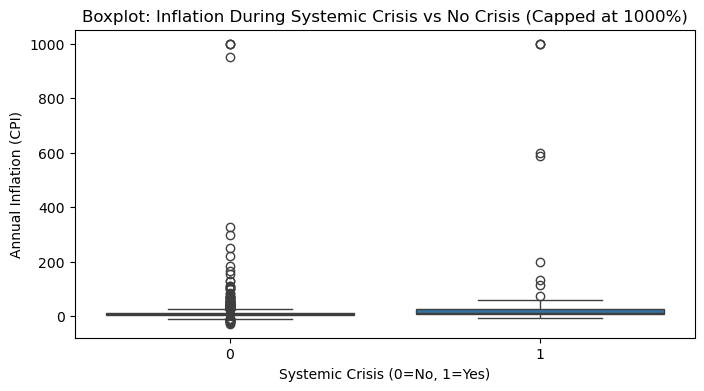

In [38]:
# cap inflation at 1000%, mean value above 1000% will set as 1000% 
df['inflation_capped'] = df['inflation_annual_cpi'].apply(lambda x: min(x, 1000))

#create figure with size  and resolution
fig = plt.figure(figsize=(8, 4), dpi=100)
#boxplot
sns.boxplot(x='systemic_crisis', y='inflation_capped', data=df)
plt.title('Boxplot: Inflation During Systemic Crisis vs No Crisis (Capped at 1000%)')
plt.xlabel('Systemic Crisis (0=No, 1=Yes)')
plt.ylabel('Annual Inflation (CPI)')
#display capped boxplot
plt.show()
#save fig
fig.savefig("capped_boxplot.png")


As observed in the boxplot, the median inflation (indicated by the horizontal line within the box) during crisis periods (Systemic Crisis = 1) is significantly higher than that during non-crisis periods (Systemic Crisis = 0).

5. Bar chart of average capped inflation

We will also use a bar chart to compare the average inflation between systemic crisis years (when a financial crisis occurred) and non-crisis years (when no crisis occurred). The primary goal of this analysis is to visually explore whether inflation tends to be higher during years when a systemic crisis happens.

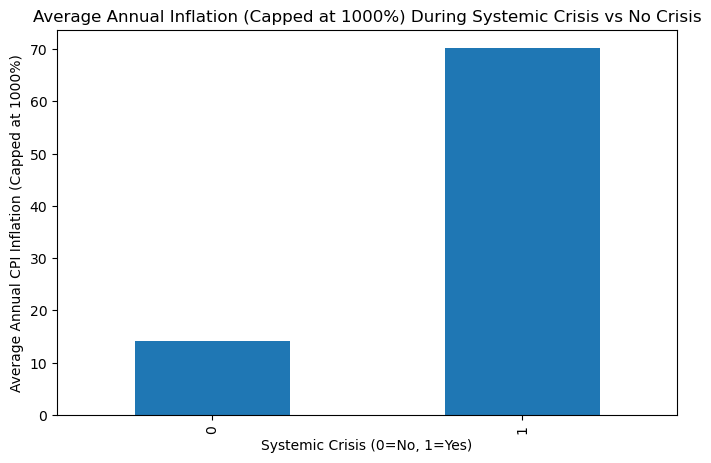

In [43]:
#create a new column with inflation capped at 1000
df['inflation_annual_cpi_capped'] = df['inflation_annual_cpi'].apply(lambda x: min(x, 1000))

#calculate the average of capped inflation by systemic crisis 
mean_inflation_capped = df.groupby('systemic_crisis')['inflation_annual_cpi_capped'].mean()

#create figure
fig = plt.figure(figsize=(8, 5), dpi=100)
#create barchart 
mean_inflation_capped.plot(kind='bar')
plt.title('Average Annual Inflation (Capped at 1000%) During Systemic Crisis vs No Crisis')
plt.xlabel('Systemic Crisis (0=No, 1=Yes)')
plt.ylabel('Average Annual CPI Inflation (Capped at 1000%)')
#display barchart
plt.show()
#save figure
fig.savefig("barchart.png")

The calculated average capped inflation values for both crisis and non-crisis groups are printed below to ensure they align with the bar chart.

In [46]:
print(mean_inflation_capped)

systemic_crisis
0    14.092813
1    70.176560
Name: inflation_annual_cpi_capped, dtype: float64


6. Conclusion:

The exploratory analysis using boxplots and bar charts offers clear visual proof that inflation rates are typically higher in years of systemic crisis than in non-crisis years in African nations. This strengthen the hypothesis that there is a strong link between high inflation and the occurrence of systemic financial crises in African nations. This insight is crucial for policymakers and financial regulators, as it highlights the need for careful observation of inflation rates as an early warning indicator. 

## Research Question 2  
**Can we predict whether a systemic financial crisis will occur based on economic indicators in African countries, and which features are most influential in these predictions?**

**Importing Required Libraries**

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

We imported essential Python libraries for data manipulation, visualization, and machine learning.

**Load and Prepare the Dataset**

In [55]:
df = pd.read_csv("african_crises.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

the data is cleaned and complete, but we notice that banking crisis is stored as type object, which can make it harder to deal with, to fix this we can map the strings 'no_crisis' and 'crisis' as integers 0 and 1

In [59]:
df['banking_crisis'] = df['banking_crisis'].map({'crisis': 1, 'no_crisis': 0})

df.info() #double check to make sure the change was successful

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

**Define Features and Target Variable**

In [62]:
target = 'systemic_crisis'

features = [
    'inflation_annual_cpi',
    'exch_usd',
    'domestic_debt_in_default',
    'sovereign_external_debt_default',
    'gdp_weighted_default',
    'independence',
    'currency_crises',
    'inflation_crises',
    'banking_crisis'
]


We define the target variable `systemic_crisis` and include related economic indicators as input features.

**Clean and Split the Data**

In [66]:
df_model = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


We handle missing values, scale the features, and split the data into training and testing sets.

**Train Random Forest Model**

We train a Random Forest Classifier with class balancing and make predictions using a custom probability threshold.

In [71]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_model.fit(X_train_scaled, y_train)

# Predict probabilities and apply custom threshold (0.3)
y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_probs >= 0.3).astype(int)


**Evaluate Model Performance & Feature Importance**

Accuracy: 0.9858490566037735

Confusion Matrix:
 [[192   3]
 [  0  17]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       195
           1       0.85      1.00      0.92        17

    accuracy                           0.99       212
   macro avg       0.93      0.99      0.96       212
weighted avg       0.99      0.99      0.99       212



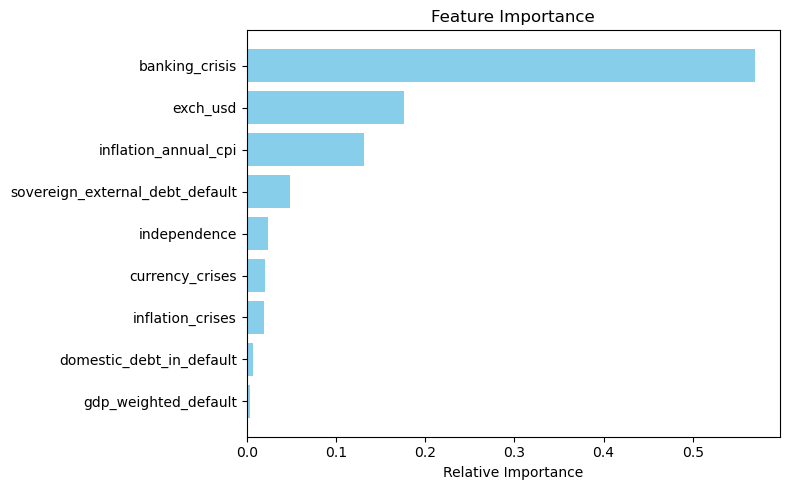

In [74]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.title('Feature Importance')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()



The bar chart above shows how much each economic indicator contributed to the model’s predictions. Features with higher importance values had a stronger influence on whether the model predicted a systemic crisis. For example, indicators like **banking crisis**, **exchange rate**, and **inflation (annual CPI)** played a larger role in identifying crisis years compared to other variables.


**Random Prediction Showcase Table**

In [78]:
df_model_full = df[features + ['systemic_crisis', 'country', 'year']].replace([np.inf, -np.inf], np.nan).dropna()

X_test_df = X_test.copy()
X_test_df['country'] = df_model_full.iloc[X_test.index]['country'].values
X_test_df['year'] = df_model_full.iloc[X_test.index]['year'].values
X_test_df['actual'] = y_test.values
X_test_df['predicted'] = y_pred

X_test_df['actual'] = X_test_df['actual'].map({1: 'crisis', 0: 'no_crisis'})
X_test_df['predicted'] = X_test_df['predicted'].map({1: 'crisis', 0: 'no_crisis'})

X_test_df['result'] = np.where(X_test_df['actual'] == X_test_df['predicted'], 'Match', 'Mismatch')

sample_showcase = X_test_df[['country', 'year', 'predicted', 'actual', 'result']].sample(10)
sample_showcase.reset_index(drop=True)


,country,year,predicted,actual,result
0,South Africa,1952,no_crisis,no_crisis,Match
1,Algeria,1873,no_crisis,no_crisis,Match
2,Zimbabwe,2010,no_crisis,no_crisis,Match
3,Zimbabwe,1965,no_crisis,no_crisis,Match
4,Algeria,1993,no_crisis,no_crisis,Match
5,Kenya,1972,no_crisis,no_crisis,Match
6,Zambia,1965,no_crisis,no_crisis,Match
7,Zambia,1949,no_crisis,no_crisis,Match
8,Algeria,2008,no_crisis,no_crisis,Match
9,Zimbabwe,2008,crisis,crisis,Match


**Conclusion**

After training and optimizing a Random Forest model to predict **systemic financial crises** using key economic indicators, the model achieved **excellent performance** on the test set:

**Accuracy**: 98.6%

**Crisis Recall**: 100% –> the model correctly identified all actual crisis years

**Crisis Precision**: 85% –> when the model predicts a crisis, it's usually correct

**Overall F1-score**: 0.99 (very strong balance between precision and recall)

#### Confusion Matrix:
|                | Predicted: No Crisis | Predicted: Crisis |
|-|----------------------|--------------------|
| **Actual: No Crisis**| 192         | 3   |
| **Actual: Crisis**| 0       | 17        |

This means the model is highly accurate overall..


These results show that with the right features and balancing techniques, it is indeed possible to **predict systemic financial crises in African countries** with high reliability using historical economic data.

In addition to making accurate predictions, the model revealed which indicators were most influential in forecasting systemic financial crises. Based on the feature importance analysis, the top contributors were:

- **Banking Crisis**
- **Exchange Rate (`exch_usd`)**
- **Annual Inflation (`inflation_annual_cpi`)**

These results indicate that financial system instability, currency value fluctuations, and rising prices are strong signals leading up to a crisis. With proper tuning and validation, this approach can be adapted to monitor real-time economic risk in African economies.


## Research Question 3
**Which African countries experienced the highest frequency of financial crises, and what economic patterns preceded them?**

1. We first would like to check how many crises occured for each African countries and see which african countries have the most crises occurs, and we will visualize it using a bar plot.

In [83]:
# Get all countries
all_countries = df['country'].unique()

# Count systemic crises per country (including zero counts)
crisis_counts_all = df[df['systemic_crisis'] == 1].groupby('country').size()

# Reindex to include all countries, fill missing with zero
crisis_counts_all = crisis_counts_all.reindex(all_countries, fill_value=0).sort_values(ascending=False)

print(crisis_counts_all)


country
Central African Republic    19
Zimbabwe                    15
Kenya                       13
Nigeria                     10
Egypt                        6
Tunisia                      5
Algeria                      4
Ivory Coast                  4
Zambia                       4
Morocco                      2
Angola                       0
Mauritius                    0
South Africa                 0
dtype: int64


We will then visualize it using the bar plot.

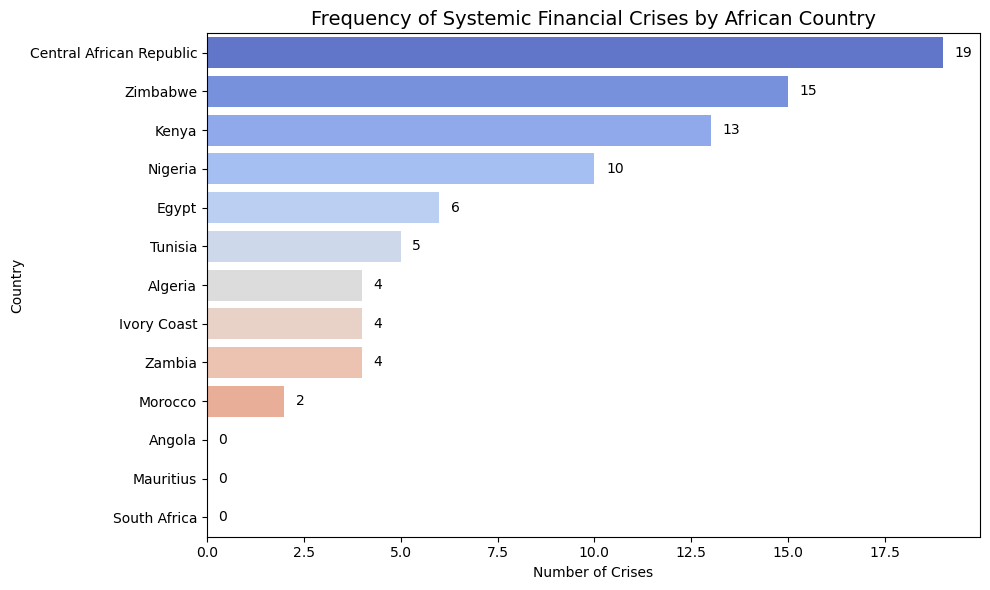

In [86]:
# Plot
fig = plt.figure(figsize=(10, 6))
ax = sns.barplot(x=crisis_counts_all.values, y=crisis_counts_all.index, palette='coolwarm', hue=crisis_counts_all.index, legend=False)

# Add count labels on bars to be able to see clearer
for i, v in enumerate(crisis_counts_all.values):
    ax.text(v + 0.3, i, str(v), color='black', va='center')

plt.title('Frequency of Systemic Financial Crises by African Country', fontsize=14)
plt.xlabel('Number of Crises')
plt.ylabel('Country')
plt.tight_layout()
plt.show()
fig.savefig("barplot.png") 

Analysis:

The bar plot illustrates the frequency of systemic financial crises experienced by African countries over the recorded years in the dataset. The Central African Republic reported the highest number of systemic crises with 19 cases, followed by Zimbabwe with 15, and Kenya with 13. Other countries such as Nigeria (10), Egypt (6), and Tunisia (5) also showed notable frequencies. Countries like Algeria, Ivory Coast, and Zambia each experienced 4 crises, while Morocco had the lowest among the top ten, with 2. While countries like Angola, Mauritius and South Africa have no financial crises occur.

This distribution indicates that certain countries—particularly the Central African Republic and Zimbabwe—may have faced recurring economic instability. These patterns could warrant further investigation into the economic conditions or political contexts that preceded or coincided with these crises.

2. Next we would like check the years where the financial crises occurs.

In [91]:
# Filter rows where a financial crisis occurred
crisis_events = df[df['systemic_crisis'] == 1]

# Group by country and list the years of crises
crisis_years_by_country = crisis_events.groupby('country')['year'].apply(list)

# Display the result
crisis_years_df = crisis_years_by_country.reset_index()
crisis_years_df.columns = ['Country', 'Years of Crises']
pd.set_option('display.max_colwidth', None) # None so that we could view all the years
print(crisis_years_df)



                    Country  \
0                   Algeria   
1  Central African Republic   
2                     Egypt   
3               Ivory Coast   
4                     Kenya   
5                   Morocco   
6                   Nigeria   
7                   Tunisia   
8                    Zambia   
9                  Zimbabwe   

                                                                                                      Years of Crises  
0                                                                                            [1870, 1990, 1991, 1992]  
1  [1976, 1977, 1978, 1979, 1980, 1981, 1982, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999]  
2                                                                                [1907, 1931, 1980, 1981, 1982, 1983]  
3                                                                                            [1988, 1989, 1990, 1991]  
4                                      [1985, 1986, 1987, 

3. Then we could find what economics pattern that preceded them. We will be checking the year before the financial crises occurs. Here we will be using the inflation_annual_cpi, exch_usd, gdp_weighted_default, domestic_debt_in_default, and also sovereign_external_debt_default as the indicators that we will be checking. 

In [103]:
# we calculate the z-score (standard score) for each value within its own country group.
def z_score(group):
    return (group - group.mean()) / group.std()



# Apply z-score normalization within each country
df['inflation_z'] = df.groupby('country')['inflation_annual_cpi'].transform(z_score)
df['exchange_z'] = df.groupby('country')['exch_usd'].transform(z_score)
df['gdp_default_z'] = df.groupby('country')['gdp_weighted_default'].transform(z_score)

# get the previous year values
df['inflation_z_before'] = df.groupby('country')['inflation_z'].shift(1)
df['exchange_z_before'] = df.groupby('country')['exchange_z'].shift(1)
df['gdp_default_z_before'] = df.groupby('country')['gdp_default_z'].shift(1)

df['domestic_default_before'] = df.groupby('country')['domestic_debt_in_default'].shift(1)
df['external_default_before'] = df.groupby('country')['sovereign_external_debt_default'].shift(1)

pre_crisis = df[df['systemic_crisis'] == 1]

# Average z-score indicators
heatmap_data = pre_crisis.groupby('country')[
    ['inflation_z_before', 'exchange_z_before', 'gdp_default_z_before']
].mean()


# Add binary indicators (mean = frequency of default before crisis)
heatmap_data['domestic_default_before'] = pre_crisis.groupby('country')['domestic_default_before'].mean()
heatmap_data['external_default_before'] = pre_crisis.groupby('country')['external_default_before'].mean()

# Rename the columns
heatmap_data.columns = [
    'Inflation (Z)',
    'Exchange Rate (Z)',
    'GDP-Weighted Default (Z)',
    'Domestic Debt (Freq)',
    'External Debt (Freq)'
]

Here we will be calculating using the z-score to get the standard value within each countries for the inflation_annual_cpi, exch_usd, and gdp_weighted_default. While for domestic_debt_in_default, and sovereign_external_debt_default, we will be counting the mean or the frequency of it.

In [106]:
# Check for missing values in final heatmap data
print("Missing values per column:\n")
print(heatmap_data.isnull().sum())

print("\nCountries with any missing values:")
print(heatmap_data[heatmap_data.isnull().any(axis=1)])

Missing values per column:

Inflation (Z)               0
Exchange Rate (Z)           0
GDP-Weighted Default (Z)    6
Domestic Debt (Freq)        0
External Debt (Freq)        0
dtype: int64

Countries with any missing values:
                          Inflation (Z)  Exchange Rate (Z)  \
country                                                      
Central African Republic       0.040663          -0.249621   
Ivory Coast                   -0.386254           0.733838   
Kenya                          0.955727           0.243512   
Nigeria                        0.566995           0.989478   
Zambia                         0.488638          -0.008004   
Zimbabwe                       0.528725          -0.241125   

                          GDP-Weighted Default (Z)  Domestic Debt (Freq)  \
country                                                                    
Central African Republic                       NaN                   0.0   
Ivory Coast                                    N

We observed that the GDP-Weighted Default (Z) column contains many missing values, primarily because the original data includes a large number of 0 values. When applying z-score normalization to a series with all zeros, the standard deviation becomes zero, which results in NaN values. To address this, we filled the missing values with 0, under the assumption that the country was at a normal or average default risk.  Then we will plot the heatmap.

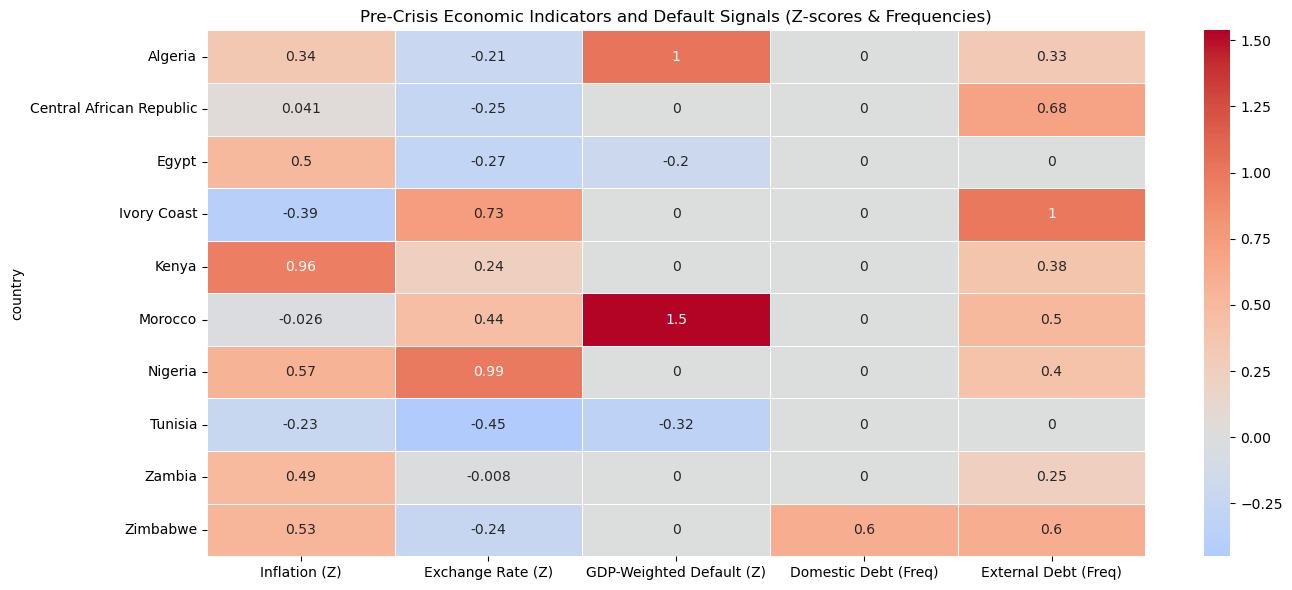

In [109]:
# Fill in the missing values with 0
heatmap_data['GDP-Weighted Default (Z)'] = heatmap_data['GDP-Weighted Default (Z)'].fillna(0)

# Plot the heatmap
fig = plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_data, annot=True, cmap="coolwarm", center=0, linewidths=0.5, mask=heatmap_data.isnull())
plt.title("Pre-Crisis Economic Indicators and Default Signals (Z-scores & Frequencies)")
plt.tight_layout()
plt.show()
fig.savefig("heatmaps.png")

Analysis:

We can observe from the heatmap that countries such as Kenya and Nigeria experienced higher-than-usual inflation in the year preceding their crises. In contrast, countries like Ivory Coast, Morocco, and Tunisia displayed lower-than-normal inflation, suggesting that inflation was not a consistent pre-crisis signal across all countries. Regarding exchange rates, countries like Nigeria, Ivory Coast, Morocco, and Kenya exhibited significantly elevated exchange rates, indicating possible currency depreciation before their crises. On the other hand, countries such as Egypt and Tunisia maintained more stable and lower exchange rates, pointing to less currency volatility in the lead-up to their crises.

For the GDP-Weighted Default (which represents the total debt in default relative to GDP), Morocco stands out as a clear outlier, with a z-score of 1.5, indicating that its debt burden was far above historical norms before the crisis. Conversely, Egypt and Tunisia had below-average levels of GDP-weighted default. Countries with a value of 0 are assumed to have had average levels of debt in default.Looking at domestic debt defaults, Zimbabwe is the only country with a notable frequency of such defaults prior to its crises, while all other countries showed no evidence of domestic defaults during pre-crisis years.

When it comes to external debt defaults, several countries experienced a high frequency of default signals before crises. Ivory Coast had the highest frequency (1.0), followed by the Central African Republic (0.68) and Zimbabwe (0.6). In contrast, Egypt and Tunisia did not experience any external defaults in the years leading up to their crises.

Conclusion:

This analysis aimed to identify which African countries experienced the highest frequency of financial crises and to explore the economic patterns preceding these events. The bar plot indicates that the Central African Republic and Zimbabwe experienced the highest number of systemic financial crises during the period studied.

The heatmap highlights the diverse economic conditions preceding systemic financial crises across African countries. While some nations, such as Kenya and Nigeria, they exhibited a clear sign of macroeconomic stress through high inflation and exchange rate pressures, others like Ivory Coast and Zimbabwe faced repeated external and domestic debt defaults. The presence of outliers, such as Morocco's unusually high GDP-weighted debt default, further emphasizes the country-specific nature of crisis triggers. Not all crises were preceded by the same warning signs. For example, Egypt and Tunisia experienced systemic crises without significant debt defaults or currency shocks. These findings suggest that while certain economic indicators can signal rising vulnerability, the path to crisis is multifaceted and context-dependent. Future work could explore additional factors or perform a comparative analysis with non-crisis years to strengthen causal interpretations.

Interestingly, countries with the highest number of systemic crises, such as the Central African Republic (19 cases), Zimbabwe (15), show distinct economic patterns in the heatmap, ranging from frequent external debts to persistent inflation. This suggests that while no single indicator guarantees a crisis, recurring financial stress patterns may help explain why some countries are more crisis-prone than others. As we can see from the heatmap, prior to the crises year, most countries experienced a high frequency of external debt followed with inflations and volatile exchange rates.


### Research Question 4
 How do economic indicators differ between banking crises, currency crises, and systemic financial crises in African countries?

This question aims to explore whether key economic indicators (such as inflation, external debt, and GDP per capita) show different patterns during banking crises, currency crises, and systemic crises. This comparison helps identify which indicators may be more relevant or specific to each crisis type.


In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
df = pd.read_csv("african_crises.csv")
df.head()

,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


In [121]:
df['banking_crisis'] = df['banking_crisis'].apply(lambda x: 1 if x == 'crisis' else 0)
df['currency_crises'] = df['currency_crises'].astype(int)
df['systemic_crisis'] = df['systemic_crisis'].astype(int)


We will analyze the distribution of the following key economic indicators during each type of crisis:
- **Inflation (inflation_annual_cpi)**
- **GDP per Capita (gdp_per_capita)**
- **Total External Debt as % of GNI (exchg_usd)**

We will use **boxplots** to visualize the differences.


In [124]:
indicators = ['inflation_annual_cpi','exch_usd','gdp_weighted_default']
crisis_types = ['banking_crisis', 'currency_crises', 'systemic_crisis']


# Melt data for seaborn
melted = pd.melt(df, id_vars=crisis_types, value_vars=indicators, var_name='Indicator', value_name='Value')
melted_long = pd.melt(melted, id_vars=['Indicator', 'Value'], value_vars=crisis_types, var_name='CrisisType', value_name='Occurred')
melted_long = melted_long[melted_long['Value'] > 0]
melted_long.head()

,Indicator,Value,CrisisType,Occurred
0,inflation_annual_cpi,3.441456,banking_crisis,1
1,inflation_annual_cpi,14.149140,banking_crisis,0
3,inflation_annual_cpi,11.203897,banking_crisis,0
7,inflation_annual_cpi,29.116045,banking_crisis,0
10,inflation_annual_cpi,3.881188,banking_crisis,0


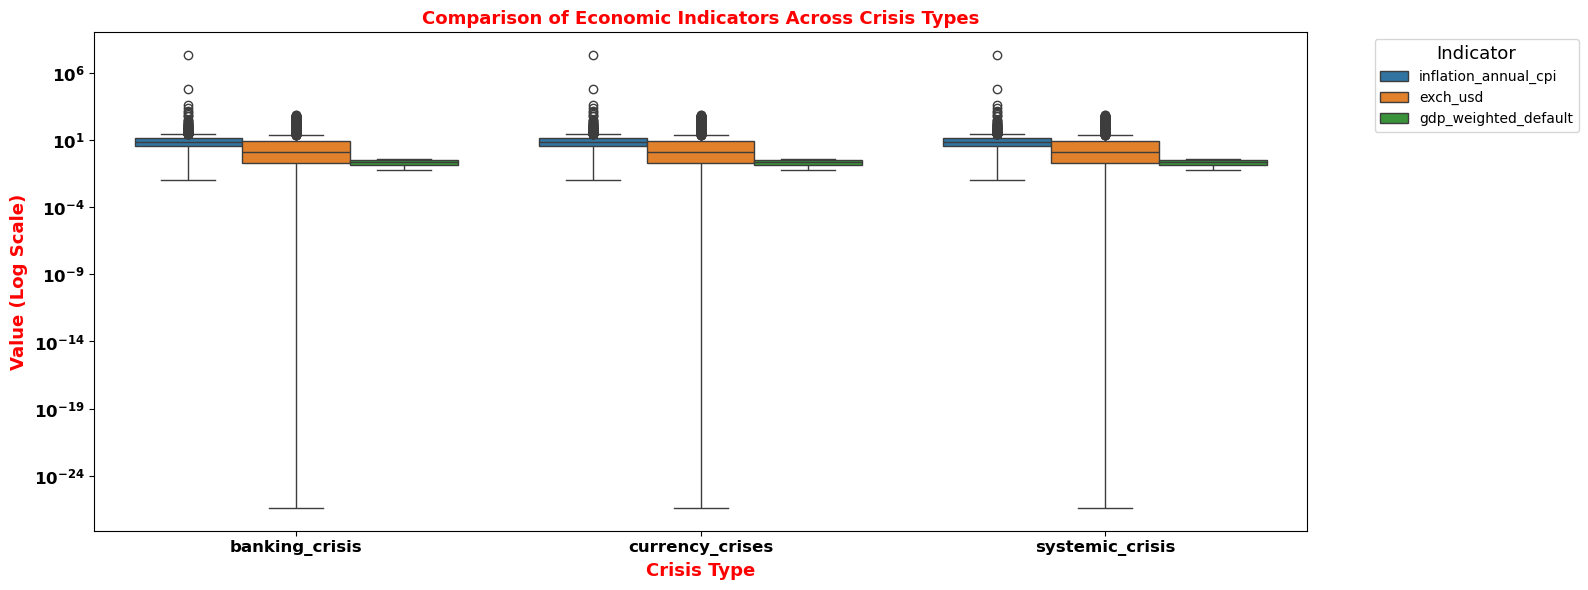

In [126]:
plt.figure(figsize=(16, 6))
sns.boxplot(data=melted_long, x='CrisisType', y='Value', hue='Indicator')
plt.title("Comparison of Economic Indicators Across Crisis Types", fontsize=13, fontweight='bold', color='red')
plt.ylabel("Value (Log Scale)", fontsize=13, fontweight='bold', color='red')
plt.xlabel("Crisis Type", fontsize=13, fontweight='bold', color='red')
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.legend(title='Indicator',title_fontsize='13', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.yscale('log')  # Handle skewed data
plt.grid(False)
plt.tight_layout()
plt.show()

**Analysis of Findings:**

- **Inflation** tends to spike particularly during **currency crises** and **systemic crises**, which is expected due to devaluation pressures and overall macroeconomic instability.
- **GDP per capita** appears to be generally lower during **systemic crises**, indicating their widespread economic impact.
- **Exchange rate (exchg_usd)** volatility is more pronounced during **currency crises**, reinforcing its role as a distinguishing factor for such events.

These patterns can help financial institutions and policymakers distinguish which indicators signal different types of crises and respond accordingly.


###  Supporting Statistics Summary

To strengthen our insights from the boxplot visualization, we computed key statistics for each crisis type:

| Crisis Type      | Median Inflation (%) | Mean Exchange Rate (USD) | Max GDP-Weighted Default |
|------------------|----------------------|---------------------------|---------------------------|
| Banking Crisis   | 12.78                | 103.39                    | 0.36                      |
| Currency Crisis  | 19.40                | 28.00                     | 0.36                      |
| Systemic Crisis  | 11.71                | 121.09                    | 0.23                      |

####  Interpretations:
- **Currency crises** show the highest **median inflation**, supporting the idea that inflation is a core symptom of monetary breakdown.
- **Systemic crises** coincide with **extreme exchange rate depreciation**, as seen in the highest average USD rates.
- **Banking and currency crises** saw the **highest GDP-weighted defaults**, reflecting their direct impact on a country's ability to service debt.

These descriptive statistics complement the visual trends and reinforce the idea that different crisis types have unique economic signatures.
